<a href="https://colab.research.google.com/drive/1OFD3yp1aZMj4YYVWIfjWSiWDj9XRHDzV"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4 - Penalized Regression - Homework by Łukasz Grzegrzółka

### Notebook author: Szymon Nowakowski

# **Homework Assignment: Analyzing and Plotting Bias in Penalized Regression**

-------------------------------

In this assignment, you will explore how **Ridge** and **Lasso** regression introduce **bias** into a model to reduce **variance**, and how the choice of the regularization parameter $\lambda$ affects this trade-off. The goal is to visualize and analyze the **bias-variance trade-off** and understand the conditions under which penalization helps or hinders model performance.

## **The Question**

**How does varying the regularization parameter $\lambda$ in Ridge and Lasso regression impact the trade-off between bias and variance?**

- We will work with a synthetic dataset based on a **known** linear relationship:
  
  $$
  y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \varepsilon
  $$
  with the ground truth:
  $$
  f(X) = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots
  $$
  and noise $$\varepsilon \sim \mathcal{N}(0, \sigma^2).$$
  Remember,
  $$
  y = f(X) + \varepsilon
  $$


  Use a **high-dimensional** setting (e.g., 50 predictors) with only a few non-zero true coefficients to emphasize the effects of regularization. I stress, the $\beta_i$ coefficients should be known for this experiment and they should be mostly 0, with only a few non-zero parameters.

- Investigate how increasing $\lambda$ influences the model’s **bias**, **variance**, and **Mean Squared Error (MSE)**.
- Plot **Bias²**, **Variance**, and **MSE** on a single graph for both Ridge and Lasso models.
- Explain MSE decomposition into bias and variance and irreducibe error. Read more on the MSE decomposition if you need to.

**Does the regularization lead to an optimal trade-off point where MSE is minimized? Explain why this point exists.**

### Work plan

This homework assignment touches on a delicate subject. I recommend reading the 7.1, 7.2 and 7.3 chapters of Elements of Statistcial Learning for more in-depth information (link to the book: https://hastie.su.domains/ElemStatLearn/ ).

In the indicated chapters you will find the definition of a test error (which is an error on a new independent test sample - conditioned on training data which is fixed) and we are usually interested in that quantity. This is however very difficult to theoretically analyse it and usually we would be happy with analasis of the value of expected prediction error, which is the test error expectation (i.e. averaged also over training data). See equations (7.2) and (7.3) in chapter 7.2.

The expected prediction error, which is, as I said, the expectation of the test error (including over the training data), can then be further decomposed into the irreducible error, variance and bias (chapter 7.3).

This can be understood as follows:

- to compute the variance of model predictions, we need to compute multiple models and see what is the variance of their output.
- to compute the bias of model predictions, we need to compute multiple models and see what is the bias of their output (vs. the groud truth that we know).

An example of the analysis similar to what we want to do in our homework is given in Chapter 7.3.1.

What follows from this analysis, is the following work plan for your current homework assignment:

1. You need to fix a model true beta coefficients. Remember to have only a few non-zero beta coeffcients, with the rest of beta coefficients equal to 0.
2. You need to assume a data distribution for your data $X$. Use normal or use your imagination.
3. Draw a large test set (draw $X_\text{test}$ and draw error $\varepsilon_\text{test}$ and compute $Y_\text{test}$) you will subsequently use for testing bias, variance and square error.
4. Vary $\lambda$ values. Use on a geometric scale for this!
   
   a. For a given fixed $\lambda$ value, you need to repeat the following procedure say 100 times:

      * Draw a new training sample (draw new $X_\text{train}$ from data distribution and draw error for computing Ys)

      * Estimate a model (lasso or ridge)

   b. At this point you have multiple models (say 100 models)

   c. Estimate the bias and variance and MSE on each point of the test set

   d. For estimation of the bias, bear in mind that it is
   $$
    Bias(\hat{f}(x_\text{test})) = E[\hat{f}(x_\text{test})] - f(x_\text{test})
   $$
   Use the ground truth as given by the ideal (not known) model $f(x_\text{test})$, **not** the noisy observation $f(x_\text{test})+\varepsilon$. Otherwise you will include the irreducible error term within your bias.
   **Irreducible error part equal to zero is a sure sign that you did this!**

   e. For a given $\lambda$ value, the bias, variance and MSE estimates will be averaged over involved trainings and over the test set.




### Expected Outcome
 - As $\lambda$ increases:
   - **Irreducible error** stays fixed **and nonzero**.
   - **Bias** increases (the model becomes too simple).
   - **Variance** decreases (the model becomes more stable).
   - **MSE** forms a **U-shape**, revealing the optimal trade-off.

- Analyze how **Ridge** and **Lasso** differ in terms of their bias-variance trade-offs.
- Discuss situations where one method may outperform the other, considering factors like **feature sparsity** and **multicollinearity**.


## **Colab Notebook Requirements**
- Your **Colab notebook** should:
  - Simulate the synthetic dataset and apply Ridge and Lasso regression.
  - Plot **Bias²**, **Variance**, and **MSE** against $\lambda$ for both models.
  - Include a section answering the questions.
  - Be well-documented with comments and explanations for each step.


## **Publish on GitHub**
- Upload your Colab notebook to your **GitHub repository** for this course.
- In your repository’s **README**, include a **link** to the notebook.
- In the notebook include **“Open in Colab”** badge so the notebook can be launched directly from GitHub.


### Definicje funkcji do generowania zbiorów testowego i zbiorów treningowych

Poniższe funkcje służą do przeprowadzenia eksperymentu, który pokazuje, jak model myli się podczas nauki.

1. `generate_linear_data`: Tworzy jeden duży „idealny świat” (zbiór testowy), losuje wartości współczynników liniowych modelu ($\beta$), oraz oblicza, jaki wynik model powinien podać, gdyby nie było szumu. Zwraca oryginalny zbiór punktów X, zaszumiony wynik eksperymentu $y = f(X) + \epsilon$, współczynniki $\beta$ oraz informacje o tym, które indeksy współczynników $\beta$ są niezerowe.
2. `generate_training_data`: Pozwala nam wielokrotnie losować małe zestawy danych do nauki, według tych samych parametrów rozkładu jak `generate_linear_data`. Dzięki temu sprawdzamy, jak bardzo wyniki modelu zmieniają się w zależności od tego, na jakim konkretnie przykładzie się uczył.
3. `bias` i `mse`: Te funkcje obliczają błędy. Pomagają oddzielić błąd wynikający ze zbyt prostego modelu (obciążenie) od błędu wynikającego z jego „rozchwiania” (wariancja).

In [1]:
import numpy as np

def generate_linear_data(n_samples=30000, standard_dev=1, n_features=60, n_informative=5, noise_std=3):
    """
    Tworzy syntetyczny zbiór danych do regresji liniowej:
    y = X * beta + noise
    gdzie beta ma tylko n_informative niezerowych współczynników.
    """

    rng = np.random.default_rng()

    # 1. Generujemy macierz X
    X = rng.normal(0, standard_dev, size=(n_samples, n_features))

    # 2. Tworzymy wektor beta
    beta = np.zeros(n_features)
    informative_idx = rng.choice(n_features, size=n_informative, replace=False)
    beta[informative_idx] = rng.uniform(1, 3, size=n_informative) * rng.choice([-1, 1], size=n_informative)

    # 3. Obliczamy f(X)
    f_X = X @ beta

    # 4. Szum gaussowski
    noise = rng.normal(0, noise_std, size=n_samples)
    y = f_X + noise

    return X, y, beta, informative_idx


def generate_training_data(beta, n_samples=200, standard_dev=0.5, noise_std=1):
    """
    Tworzy zbiory do trenowania modeli w kroku 4, zwraca wylosowany X i odpowiadajacy mu y z szumem
    """
    rng = np.random.default_rng()
    X = rng.normal(0, standard_dev, size=(n_samples, beta.size))
    y = X @ beta + rng.normal(0, noise_std, size=n_samples)
    return X, y


def bias(f_X, y_pred):
    return y_pred.mean(axis=0) - f_X

def mse(y_true, y_pred):
    return ((y_pred - y_true)**2).mean(axis=0)

### Analiza wyników i wizualizacja

Dalsza część kodu odpowiada za przeprowadzenie właściwego eksperymentu oraz narysowanie wyników:

1. `test_model`: To główny silnik symulacji. Dla każdej wartości parametru $\alpha$ (siły kary), funkcja powtarza proces uczenia modelu 100 razy na różnych zestawach danych. Za każdym razem model jest najpierw standaryzowany (`StandardScaler`), a następnie dopasowywany do danych treningowych. Funkcja zbiera wszystkie przewidywania, a potem oblicza z nich średnie wartości błędu obciążenia ($Bias^2$), wariancji oraz całkowitego błędu MSE. Na koniec wylicza też błąd nieredukowalny, sprawdzając, czy suma biasu i wariancji faktycznie pokrywa się z całkowitym błędem (zgodnie z teorią matematyczną).
2. `draw_test_results`: Ta funkcja zamienia liczby w czytelny wykres. Rysuje ona trzy linie: czerwoną dla rosnącego obciążenia, niebieską dla malejącej wariancji oraz grubą czarną linię dla błędu MSE. Dzięki skali logarytmicznej na osi X, możemy łatwo dostrzec „punkt idealny” – czyli taką wartość $\alpha$, dla której czarna linia MSE znajduje się najniżej. Dodatkowo, żółta linia pozwala nam zweryfikować, czy dekompozycja błędu została wykonana poprawnie i pokrywa się z teoretycznymi założeniami.

In [2]:
import numpy as np
from sklearn.linear_model import Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
from tqdm import tqdm


def test_model(reg_model, X, y, beta, standard_dev=1, n_simulations=100, n_train_samples=150, alphas=np.geomspace(1e-4, 20, 100), noise_std=3):
    """
    Dopasowuje 'reg_model' do danych treningowych i oblicza bias, oraz wariancję na danych testowych, a także MSE
    """
    f_X = X@beta

    biases = np.zeros((alphas.size, y.size))
    variances = np.zeros((alphas.size, y.size))
    MSEs = np.zeros((alphas.size, y.size))

    for k in tqdm(range(alphas.size)):
        model_predictions = np.zeros((n_simulations, y.size))
        for i in range(n_simulations):
            model = make_pipeline(StandardScaler(), reg_model(alpha=alphas[k]))
            X_train, y_train = generate_training_data(beta, n_samples=n_train_samples, standard_dev=standard_dev, noise_std=noise_std)
            model.fit(X_train, y_train)
            model_predictions[i] = model.predict(X)
        biases[k] = bias(f_X, model_predictions)
        variances[k] = model_predictions.var(axis=0)
        MSEs[k] = mse(y, model_predictions)

    biases2 = np.copy(biases)**2
    #mean_biases = biases.mean(axis=1)
    mean_biases2 = biases2.mean(axis=1)
    mean_variances = variances.mean(axis=1)
    mean_MSEs = MSEs.mean(axis=1)
    irreducible_error = (MSEs - variances - biases2).mean(axis=1)

    return alphas, mean_biases2, mean_variances, mean_MSEs, irreducible_error


def draw_test_results(alphas, mean_biases2, mean_variances, mean_mses, irreducible_error=None, ylim=None):
    _, ax = plt.subplots(1,1, figsize=(10, 7))
    ax.plot(alphas, mean_biases2, color="red", label=r"Mean bias$^2$")
    ax.plot(alphas, mean_variances, color="blue", label=r"Mean variance")
    ax.plot(alphas, mean_mses, linewidth=6, color="black", label=r"MSE")
    if not irreducible_error is None:
        ax.plot(alphas, irreducible_error, color="magenta", label="Irreducible error")
        ax.plot(alphas, irreducible_error+mean_variances+mean_biases2, linewidth=2, color="yellow", label=r"Bias$^2$ + Var + $\sigma^2$")
    ax.set_xlabel(r"$\alpha$")
    ax.set_xscale("log")
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.legend()
    plt.show()
    return


### Generujemy zbiór danych do testowania modelu

In [3]:
X, y, beta, informative_idx = generate_linear_data(n_samples=10000, standard_dev=1, n_features=60, n_informative=8, noise_std=3)

### Test modelu Lasso

In [4]:
alphas_lasso, mean_biases2_lasso, mean_variances_lasso, mean_MSEs_lasso, irreducible_error_lasso = test_model(Lasso, X, y, beta, alphas=np.geomspace(1e-3, 3, 100))

100%|██████████| 100/100 [00:40<00:00,  2.44it/s]


**Rysunek z wynikami modelu Lasso**

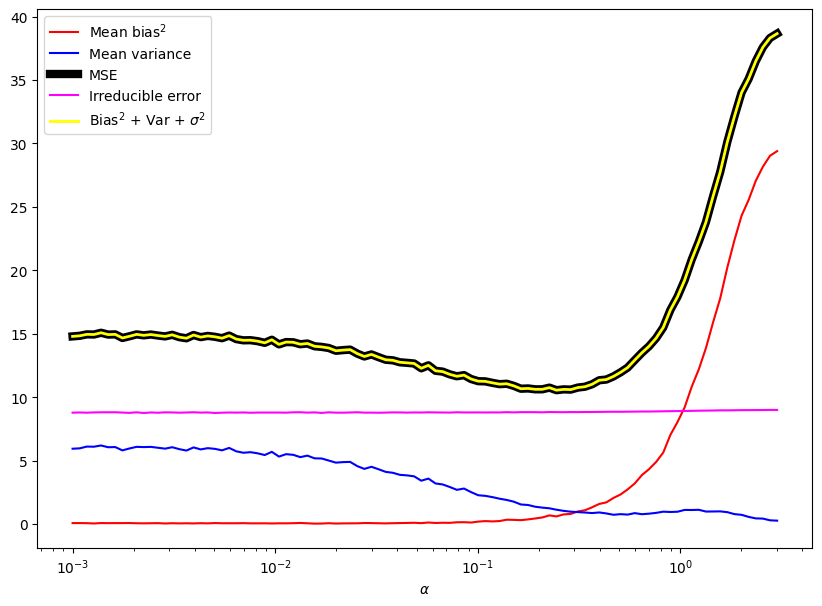

In [5]:
draw_test_results(alphas_lasso, mean_biases2_lasso, mean_variances_lasso, mean_MSEs_lasso, irreducible_error_lasso)

### Analiza wyników dla modelu Lasso


Na powyższym wykresie widzimy wyniki symulacji, ilustrujące teoretyczny kompromis między obciążeniem a wariancją (bias-variance trade-off). Zgodnie z teorią, całkowity błąd średniokwadratowy (**MSE**) modelu można rozbić na trzy składowe, co potwierdza żółta linia na wykresie pokrywająca się z grubą czarną linią:

1. **$Bias^2$** (czerwona linia): Mierzy błąd wynikający z błędnych założeń modelu. Widzimy, że rośnie on wraz ze wzrostem $\alpha$, ponieważ model staje się zbyt uproszczony.

2. **Wariancja** (niebieska linia): Mierzy, jak bardzo przewidywania modelu zmieniają się przy różnych zestawach danych treningowych. Spada ona wraz ze wzrostem $\alpha$, ponieważ kara ogranicza "rozchwianie" współczynników.

3. **Błąd nieredukowalny** (różowa linia): Wynika z szumu w danych ($\sigma^2 \approx 9$). Jak widać, pozostaje on na stałym poziomie niezależnie od modelu - jest to bariera, której nie da się przeskoczyć żadną regularyzacją.

**Interpretacja kształtu krzywej MSE**

Krzywa MSE przybiera charakterystyczny kształt z minimum U-kształtnym. Optimum wypada przy wartości $\alpha \approx 0.2$. W tym punkcie suma spadającej wariancji i rosnącego obciążenia daje najniższą wartość. To "złoty środek", w któym penalizacja jest wystarczająco silna, by zapobiec przeuczeniu (overfitting), ale na tyle słaba, by model wciąż wyłapywał istotne zależności z danych. Dzięki temu model najlepiej generalizuje, czyli radzi sobie z danymi, których wcześniej nie widział. Przy niskiej regularyzacji (lewa strona wukresu) model ma niskie obciążenie, ale wysoką wariancję. Jest zbyt elastyczny i dopasowuje się do przypadkowego szumu w małej próbie treningowej zamiast do rzeczywistego trendu. Przy wysokiej regularyzacji (prawa strona wykresu) następuje proces tzw. niedouczenia (underfitting). Zbyt wysoka kara drastycznie ogranicza wartości współczynników, "ściągając" przewidywania modelu w stronę prostej średniej. Model staje się zbyt sztywny i przestaje reagować na zmienność cech wejściowych, co skutkuje gwałtownym wzrostem błędu systematycznego ($Bias^2$).

### Test modelu Ridge

In [6]:
alphas_ridge, mean_biases2_ridge, mean_variances_ridge, mean_MSEs_ridge, irreducible_error_ridge = test_model(Ridge, X, y, beta, alphas=np.geomspace(1e-2, 1e3, 100))

100%|██████████| 100/100 [00:39<00:00,  2.52it/s]


**Rysunek z wynikami modelu Ridge**

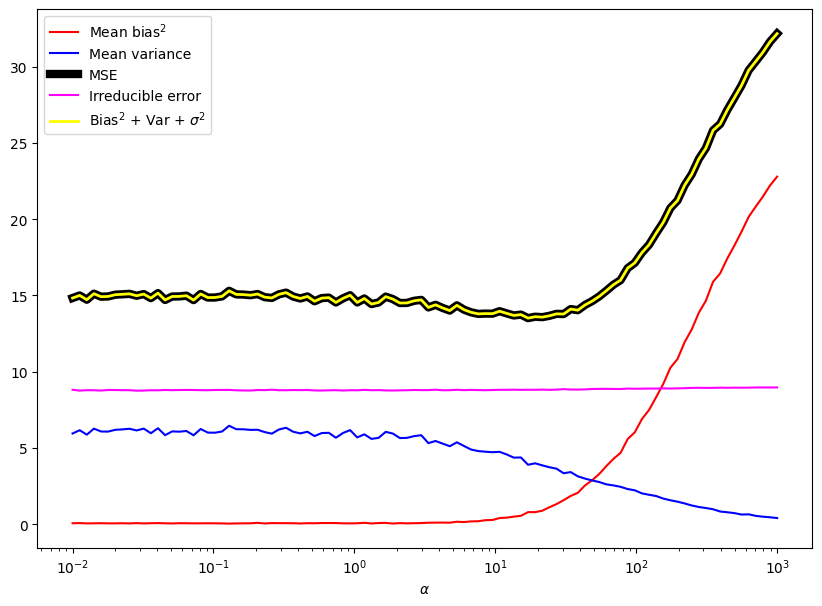

In [7]:
draw_test_results(alphas_ridge, mean_biases2_ridge, mean_variances_ridge, mean_MSEs_ridge, irreducible_error_ridge)

### Analiza wyników dla modelu Ridge

Wykres dla regresji Ridge prezentuje przebieg dekompozycji błędu MSE w funkcji parametru regularyzacji $\alpha$, potwierdzając teoretyczną spójność modelu (żółta linia sumująca składowe idealnie pokrywa się z czarną linią MSE).

Punkt minimalnego błędu **MSE** ($\alpha \approx 20$) jest przesunięty w stronę znacznie wyższych wartości $\alpha$ niż w przypadku Lasso. W tym miejscu model osiąga najlepszą zdolność generalizacji, skutecznie balansując spadek wariancji (niebieska linia) ze wzrostem obciążenia (czerwona linia). **Błąd nieredukowalny** (różowa linia), wynikający z szumu w danych pozostaje stały na poziomie ok. 9.0, stanowiąc dolną granicę błędu predykcji, której model nie może przekroczyć. Przy niskich wartościach $\alpha$ (lewa strona wykresu) model charakteryzuje się stabilną, ale wysoką wariancją i niemal zerowym obciążeniem, co sugeruje nadmierne dopasowanie do danych treningowych. Wraz ze wzrostem parametru $\alpha$ powyżej wartości optymalnej (prawa strona), następuje gwałtowny wzrost $Bias^2$. Wynika to z faktu, że silna penalizacja $L_2$ proporcjonalnie wygasza wszystkie współczynniki $\beta$, drastycznie upraszczając model i ograniczając jego zdolność do odwzorowania zmienności w danych. Wariancja systematycznie i łagodnie maleje w całym zakresie wzrostu $\alpha$, co świadczy o stabilizowaniu modelu przez karę Ridge, chociaż ostatecznie wynika to po prostu z przetrenowania przy wysokich wartościach $\alpha$ (prawa strona wykresu).

### Porównanie modeli Ridge i Lasso

Główna różnica w kompromisie między obciążeniem a wariancją (bias-variance trade-off) wynika ze sposobu, w jaki oba modele nakładają karę na współczynniki. Lasso (kara $L_1$) posiada naturalną zdolność do selekcji cech, ponieważ przy odpowiednio dużym $\alpha$ wymusza na najmniej istotnych współczynnikach wartość dokładnie równą zero. W eksperymencie, w którym tylko 8 z 60 cech było niezerowych (feature sparsity), Lasso szybciej odnajduje właściwą strukturę danych, co często pozwala mu osiągnąć niższy błąd MSE przy mniejszej liczbie zmiennych. Z kolei Ridge (kara $L_2$) jedynie proporcjonalnie zmniejsza (skaluje) wszystkie współczynniki, nigdy ich całkowicie nie zerując. To sprawia, że Ridge zazwyczaj lepiej radzi sobie w sytuacjach silnej współliniowości (multicollinearity). Zamiast wybierać jedną z silnie skorelowanych zmiennych (co robi Lasso), Ridge rozkłada karę równomiernie między nie, stabilizując wariancję modelu. Podsumowując, wybór modelu zależy od natury problemu. Lasso sprawdzi się lepiej, gdy większość cech w zbiorze to "szum" i tylko nieliczne mają realny wpływ na wynik (model staje się wtedy bardziej interpretowalny). Ridge sprawdzi się lepiej, gdy na obserwowane zjawisko ma wpływ wiele cech o podobnym znaczeniu, szczególnie gdy są one ze sobą skorelowane.